In [29]:
from transformers import AutoTokenizer, AutoModel
import torch


from src.LM.embeddings.embedder_preprocess import load_minilm_embedder, prepare_data_minilm_simple

from src.data_loader import load_data
from src.ML.train_NN_improved import (
    train_model,
    TextClassifier,
    DeepTextClassifier
)
import os
hf_token = os.getenv("HF_TOKEN")

import re

from sklearn.model_selection import train_test_split
import gensim.downloader
from nltk.tokenize import word_tokenize
import nltk     
nltk.download('punkt', quiet=True)

from src.LM.embeddings.embedder_preprocess import clean_text
from src.LM.embeddings.embedder_preprocess import load_word2vec_model
from src.LM.embeddings.embedder_preprocess import text_to_vector
from src.LM.embeddings.embedder_preprocess import prepare_data_word2vec

from src.plotting import plot_confusion_matrix, plot_learning_curve, plot_metrics_bar_chart
from sklearn.metrics import classification_report

DATA_PATH = "/home/xkubanova_126831/bakalarka/nbs_binary/data/ekosentiment_titles_binary.csv"
df = load_data(DATA_PATH)

Dataset shape: (694, 2)

Categories samples:

0:
  Príjmy vedúcich policajných funkcionárov A verejnosť tak mohla o celkových príjmoch policajnej elity u nás iba špekulovať. Jeho príjem za vlaňajšok v celkovej výške takmer 44-tisíc eur totiž prekonal viceprezident polície Ľubomír Ábel. Príjmy vedúcich policajných funkcionárov...

1:
  Analytik o osobných bankrotoch: Ich pravidlá sú podľa neho nastavené veľmi voľne "Obávam sa, že toto nastavenie bude do budúcnosti motivovať časť ľudí, aby sa nadmerne zadlžovala a následne využila osobný bankrot a začala bez dlhov. "Od štátu by som čakal také nastavenie legislatívy, ktoré ľudí navedie k právnemu a finančnému poradenstvu a riešeniu dlhov v rannej fáze problému. Búlik z OVB je pres...


In [30]:
# load word2vec
w2vmodel = load_word2vec_model()
print("Model loaded. Vector size:", w2vmodel.vector_size) 
print(df["Category"].value_counts(normalize=True))

Loading pretrained Word2Vec model from gensim…
Model loaded
Model loaded. Vector size: 300
Category
0    0.727666
1    0.272334
Name: proportion, dtype: float64


In [31]:
# Plotting functions

def plot_results(class_to_idx, preds, labels, train_losses, test_accs, prefix='nn_'):
    idx_to_class = {i: cls for cls, i in class_to_idx.items()}
    target_names = [str(idx_to_class[i]) for i in sorted(idx_to_class.keys())]

    # CLASSIFICATION REPORT
    
    print("\nClassification Report:")
    print(classification_report(labels, preds, target_names=target_names, digits=4))

    idx_to_class = {i: cls for cls, i in class_to_idx.items()}
    target_names = [str(idx_to_class[i]) for i in sorted(idx_to_class.keys())]

    plot_confusion_matrix(labels, preds, target_names, prefix=prefix)
    plot_learning_curve(len(train_losses), train_losses, test_accs, prefix=prefix)
    plot_metrics_bar_chart(labels, preds, target_names, prefix=prefix)

Loading pretrained Word2Vec model from gensim…
Model loaded
Simple Feed Forward NN — class weights
Input dimension: 300
Input dimension for NN: 300

Classification Report:
              precision    recall  f1-score   support

           0     0.7757    0.8218    0.7981       101
           1     0.4375    0.3684    0.4000        38

    accuracy                         0.6978       139
   macro avg     0.6066    0.5951    0.5990       139
weighted avg     0.6832    0.6978    0.6893       139



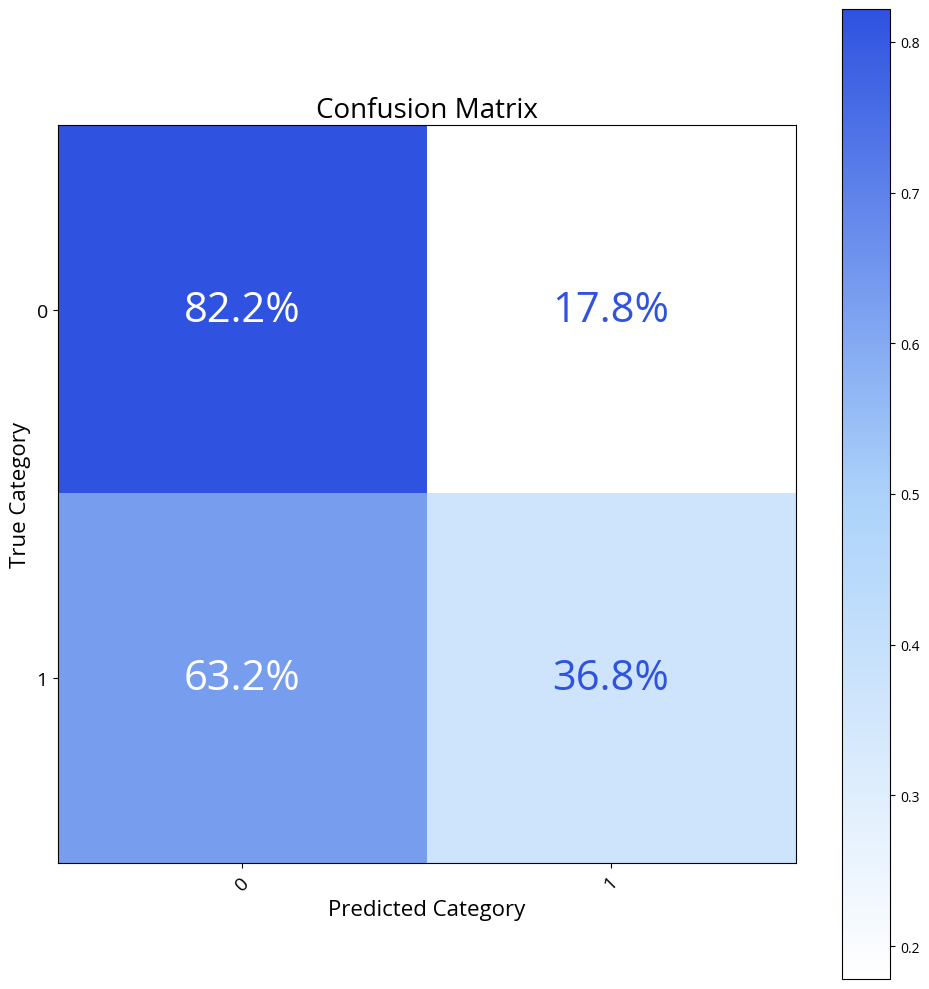

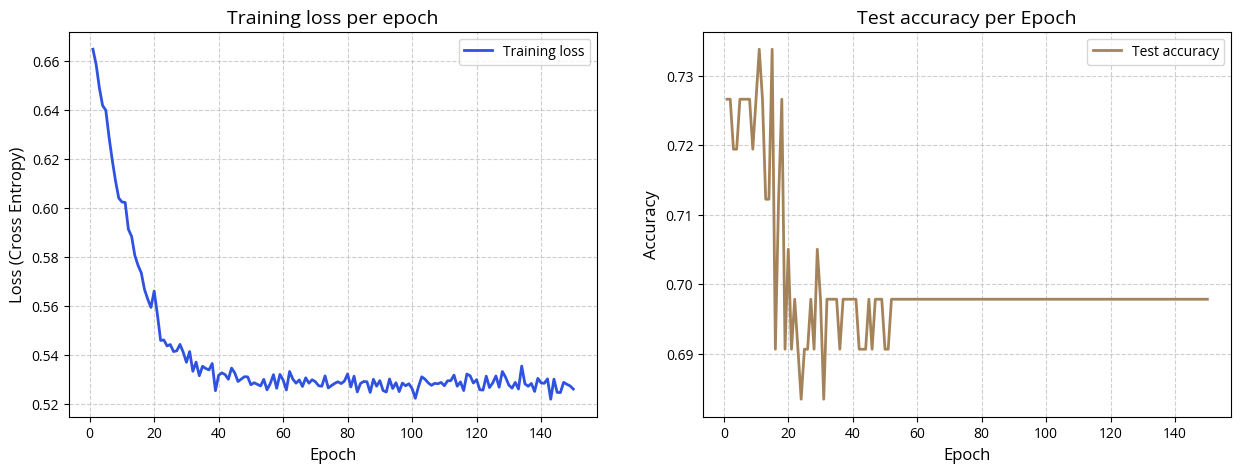

<Figure size 640x480 with 0 Axes>

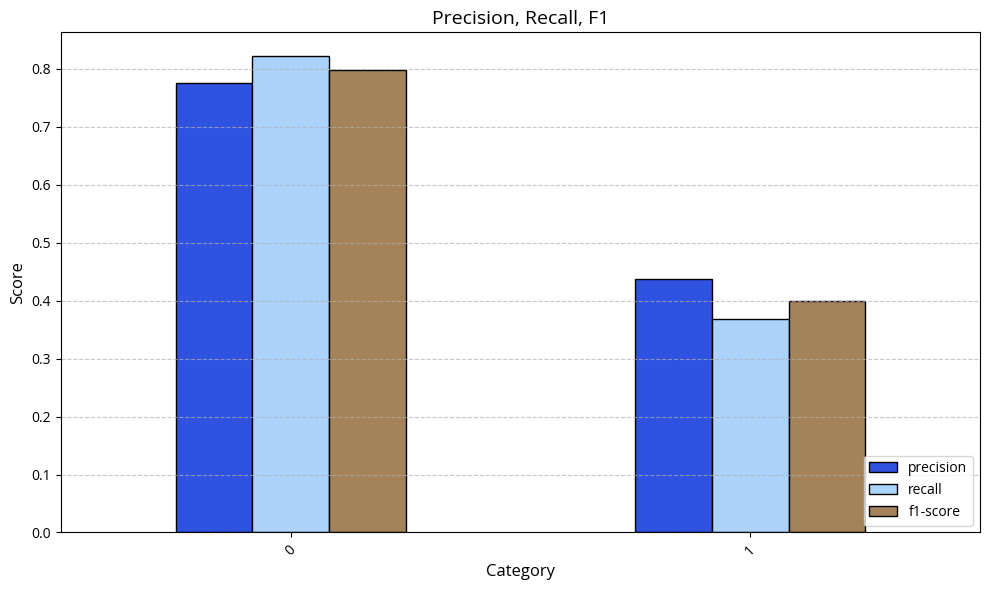

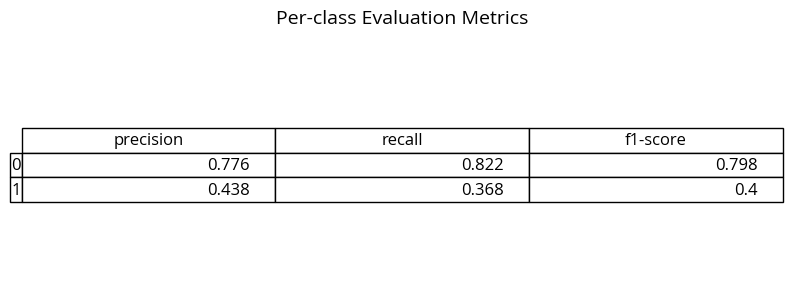

In [32]:
#Simple Feed Forward NN — Word2Vec + class weights
X_train, X_test, y_train, y_test, w2vmodel = prepare_data_word2vec(df)

print('Simple Feed Forward NN — class weights')

model, class_to_idx, preds, labels, train_losses, test_accs = train_model(
    X_train, y_train, X_test, y_test,
    model_class=TextClassifier,
    model_params={'hidden_dim': 256},
    epochs=150,
    lr=1e-3,
    class_weights=True,
    use_scheduler=True
)
print("Input dimension for NN:", X_train.shape[1])

plot_results(class_to_idx, preds, labels, train_losses, test_accs)

Deep Feed Forward NN — class weights
Input dimension: 300
Input dimension for NN: 300

Classification Report:
              precision    recall  f1-score   support

           0     0.8043    0.7327    0.7668       101
           1     0.4255    0.5263    0.4706        38

    accuracy                         0.6763       139
   macro avg     0.6149    0.6295    0.6187       139
weighted avg     0.7008    0.6763    0.6858       139



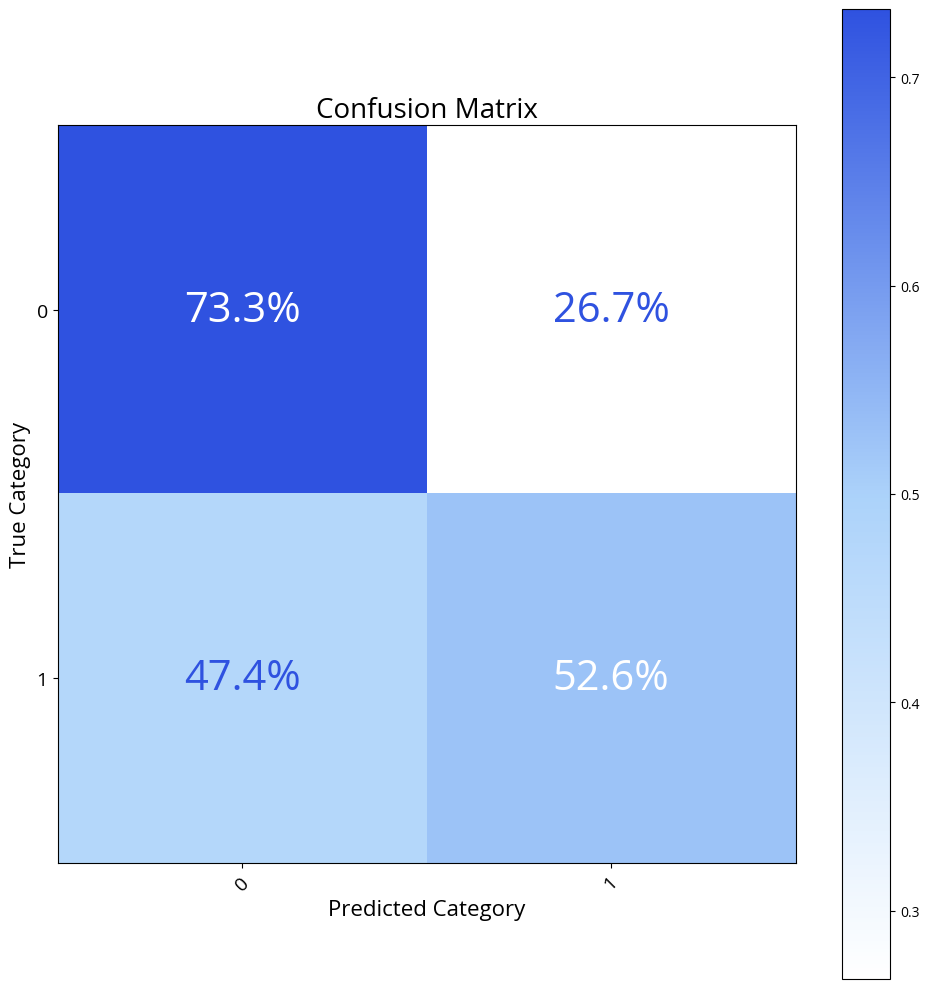

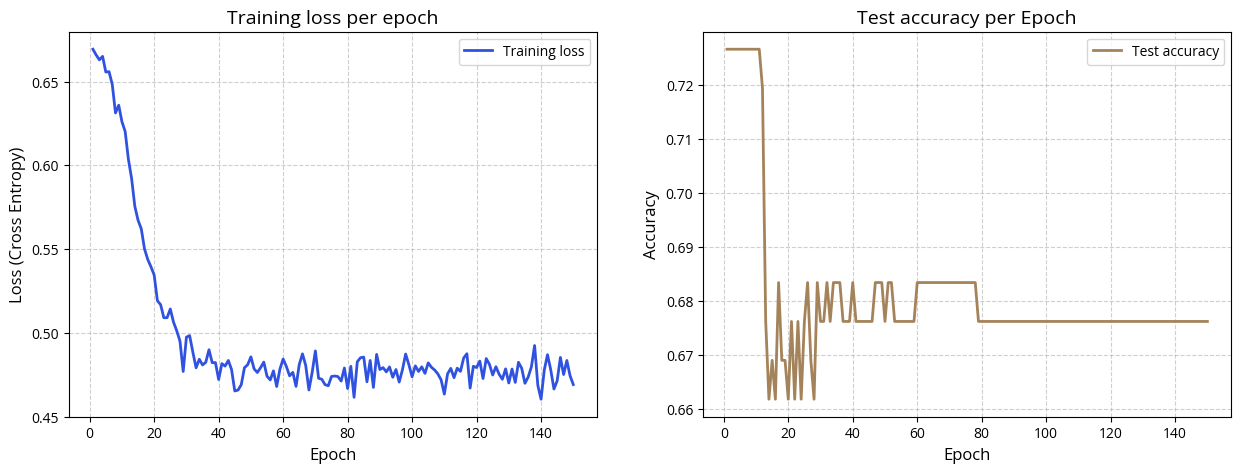

<Figure size 640x480 with 0 Axes>

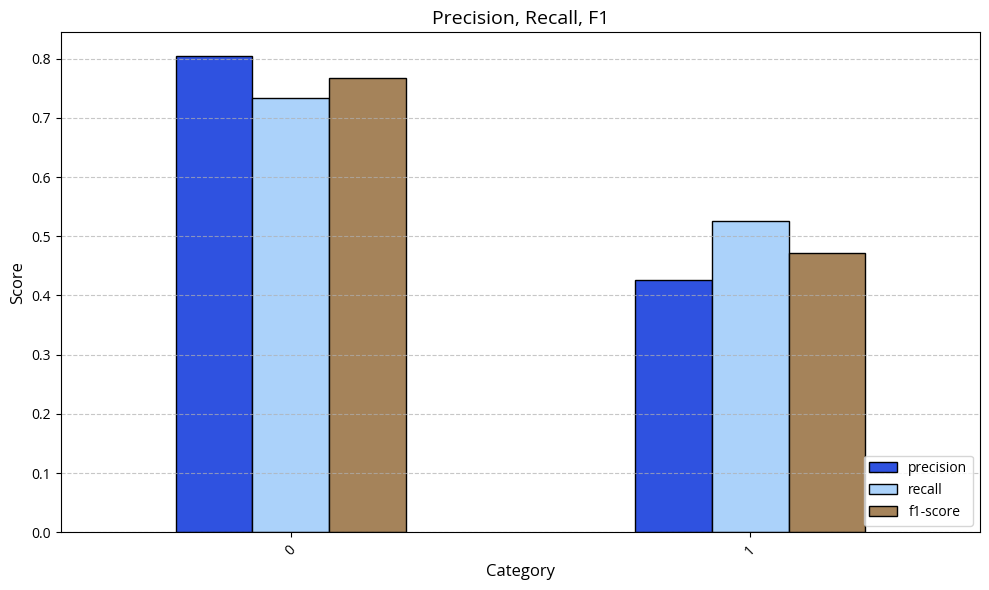

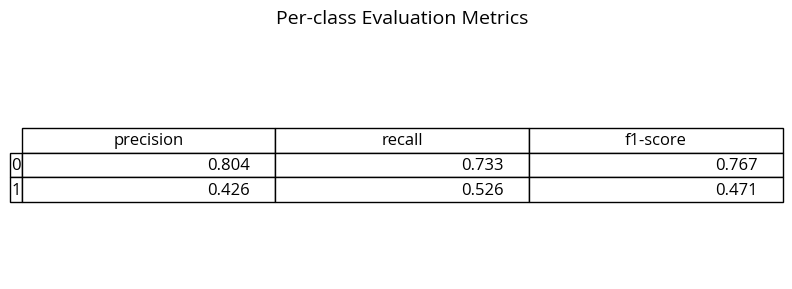

In [33]:
#Deep Feed Forward NN — Word2Vec + class weights
#X_train, X_test, y_train, y_test, w2vmodel = prepare_data_word2vec(df)

print('Deep Feed Forward NN — class weights')

model, class_to_idx, preds, labels, train_losses, test_accs = train_model(
    X_train, y_train, X_test, y_test,
    model_class=DeepTextClassifier,
    model_params={'hidden_dims': [256, 128, 64, 32]},
    epochs=150,
    lr=1e-3,
    class_weights=True,
    use_scheduler=True
)
print("Input dimension for NN:", X_train.shape[1])

plot_results(class_to_idx, preds, labels, train_losses, test_accs)

Simple Feed Forward NN — Focal Loss
Input dimension: 300


/home/xkubanova_126831/bakalarka/nbs_binary/src/ML/train_NN_improved.py:85: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float32))


Input dimension for NN: 300

Classification Report:
              precision    recall  f1-score   support

           0     0.8211    0.7723    0.7959       101
           1     0.4773    0.5526    0.5122        38

    accuracy                         0.7122       139
   macro avg     0.6492    0.6625    0.6541       139
weighted avg     0.7271    0.7122    0.7184       139



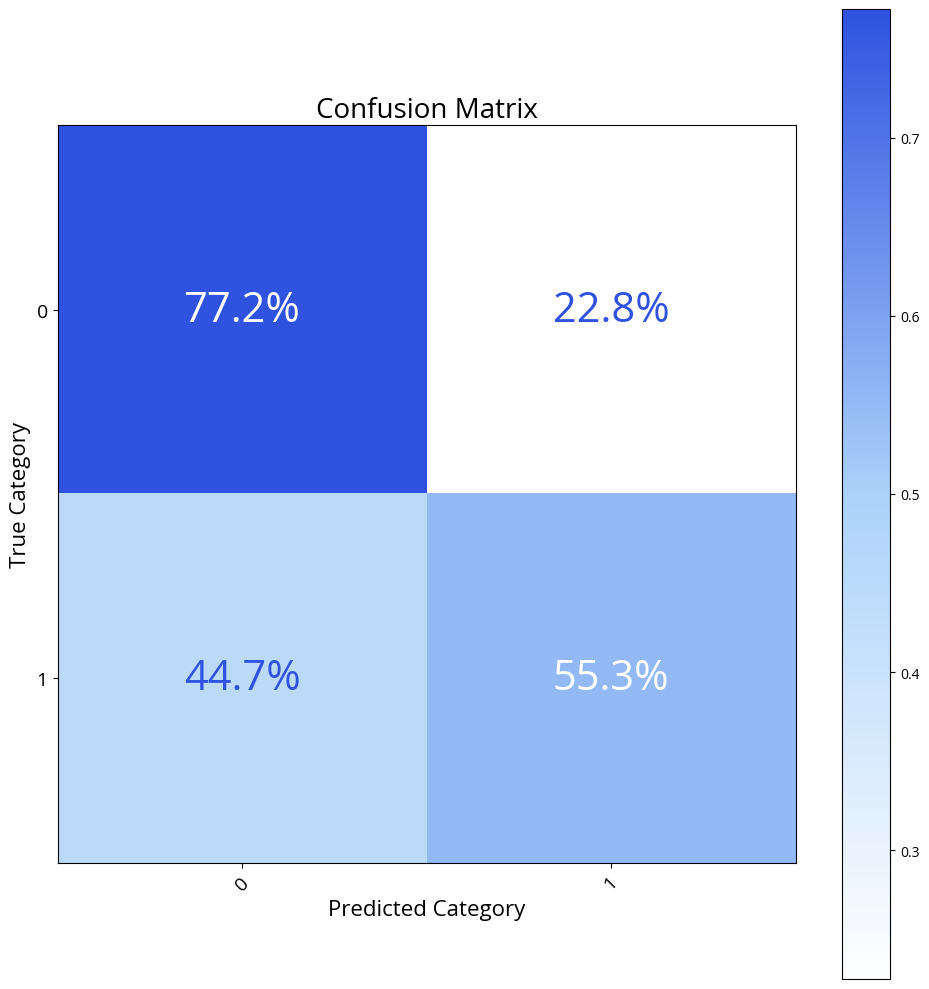

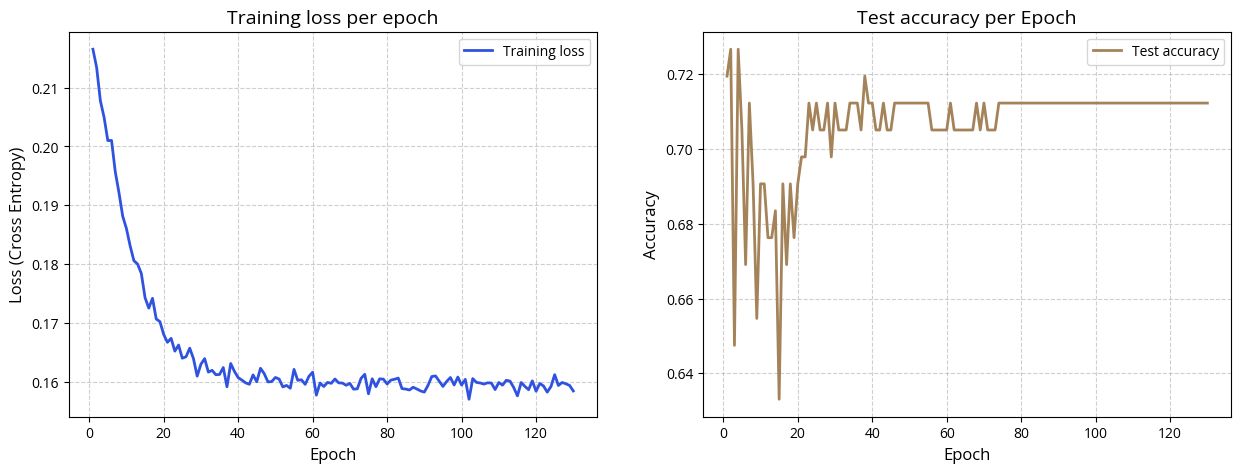

<Figure size 640x480 with 0 Axes>

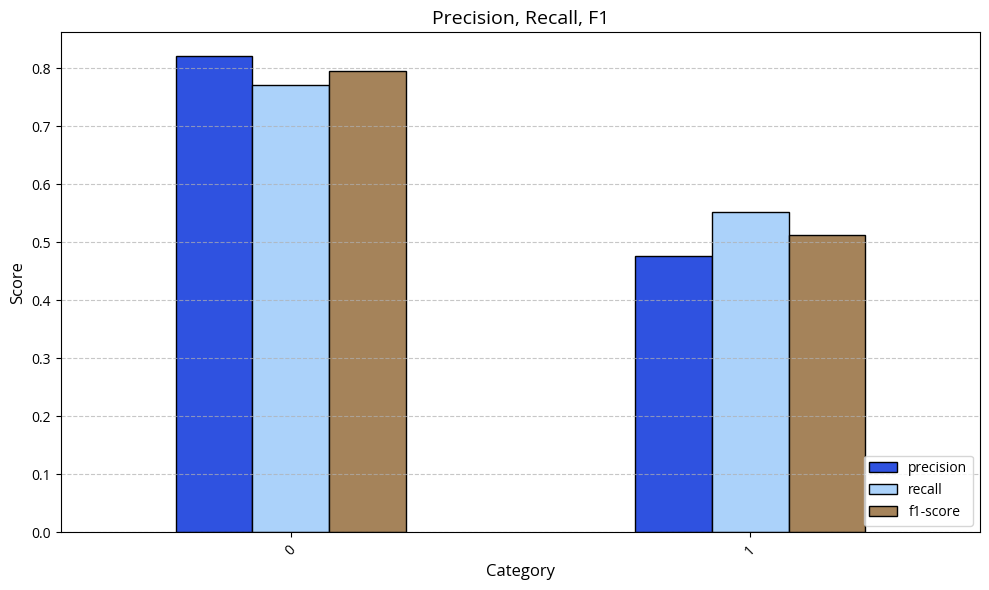

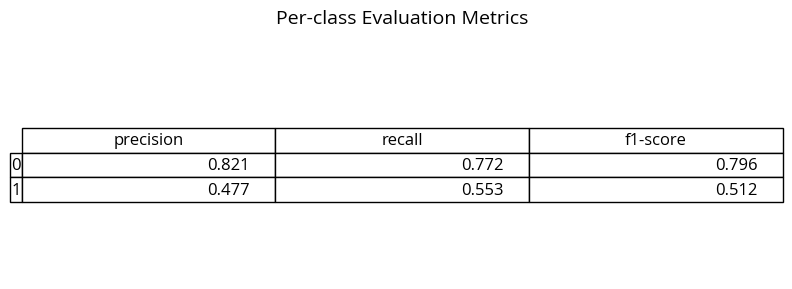

In [34]:
#Simple Feed Forward NN — Word2Vec + Focal Loss
import torch
from src.ML.train_NN_improved import FocalLoss
#X_train, X_test, y_train, y_test, w2vmodel = prepare_data_word2vec(df)

print('Simple Feed Forward NN — Focal Loss')
alpha = torch.tensor([1.0, 2.0])  # higher weight on minority class (index 1)

model, class_to_idx, preds, labels, train_losses, test_accs = train_model(
    X_train, y_train, X_test, y_test,
    model_class=TextClassifier,
    model_params={'hidden_dim': 256},
    epochs=130,
    lr=1e-3,
    loss_fn=FocalLoss(alpha=alpha, gamma=2),
    use_scheduler=True
)
print("Input dimension for NN:", X_train.shape[1])

plot_results(class_to_idx, preds, labels, train_losses, test_accs)

Deep Feed Forward NN — Focal Loss
Class counts: [404 151]
Sample weights per class: [0.00247525 0.00662252]
Input dimension: 300


Input dimension for NN: 300

Classification Report:
              precision    recall  f1-score   support

           0     0.8667    0.6436    0.7386       101
           1     0.4375    0.7368    0.5490        38

    accuracy                         0.6691       139
   macro avg     0.6521    0.6902    0.6438       139
weighted avg     0.7493    0.6691    0.6868       139



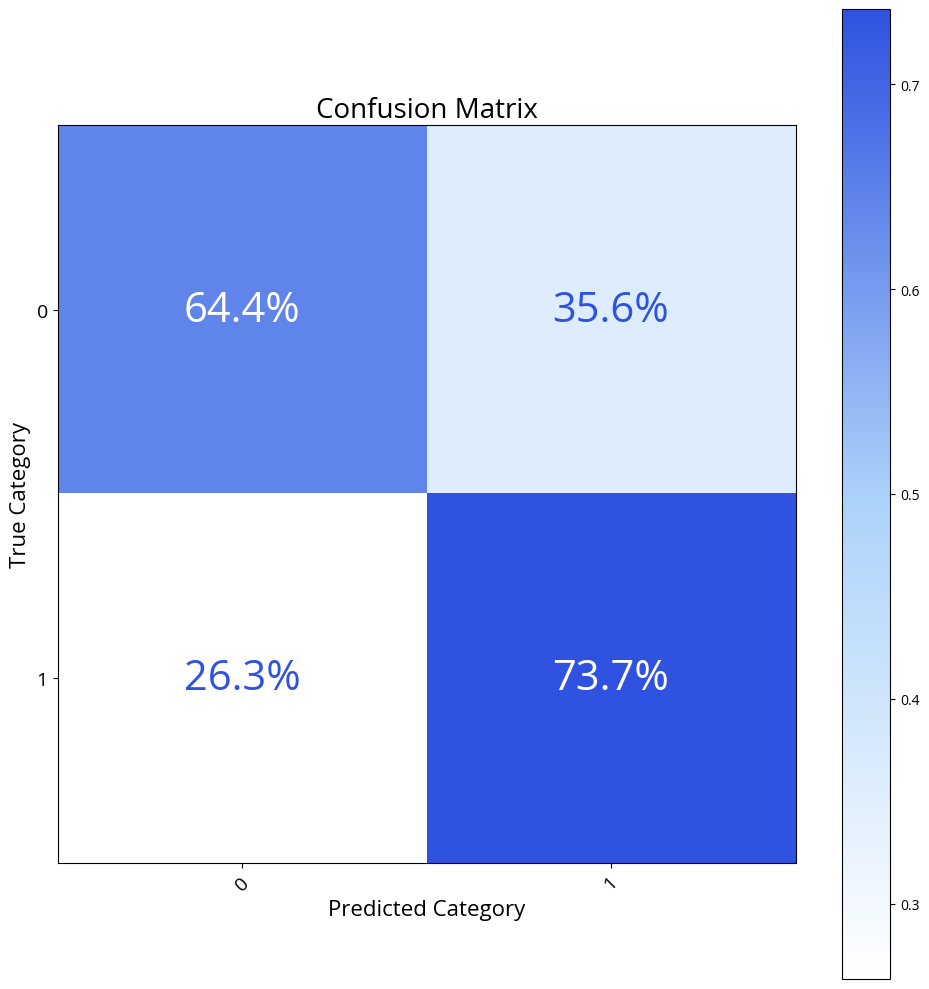

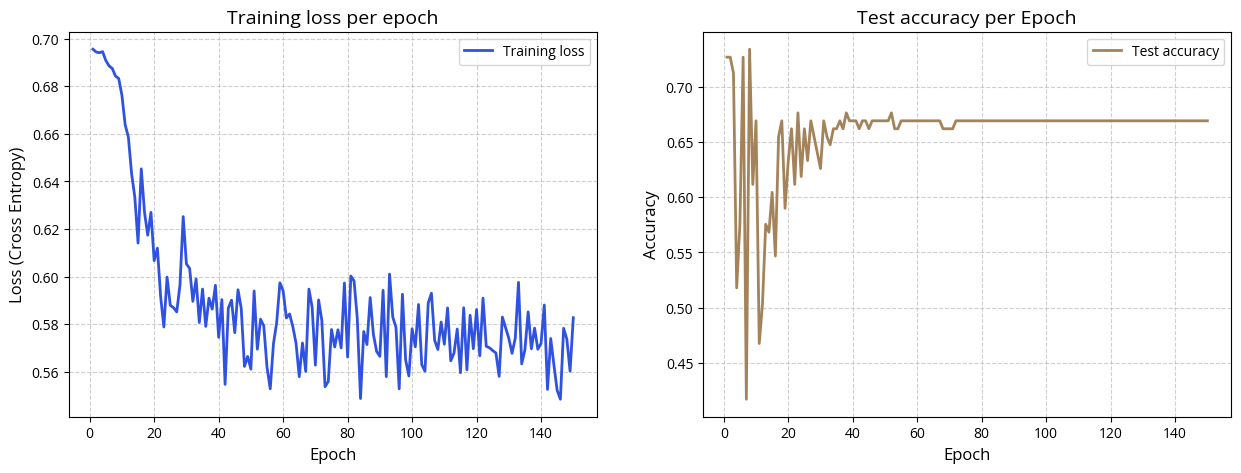

<Figure size 640x480 with 0 Axes>

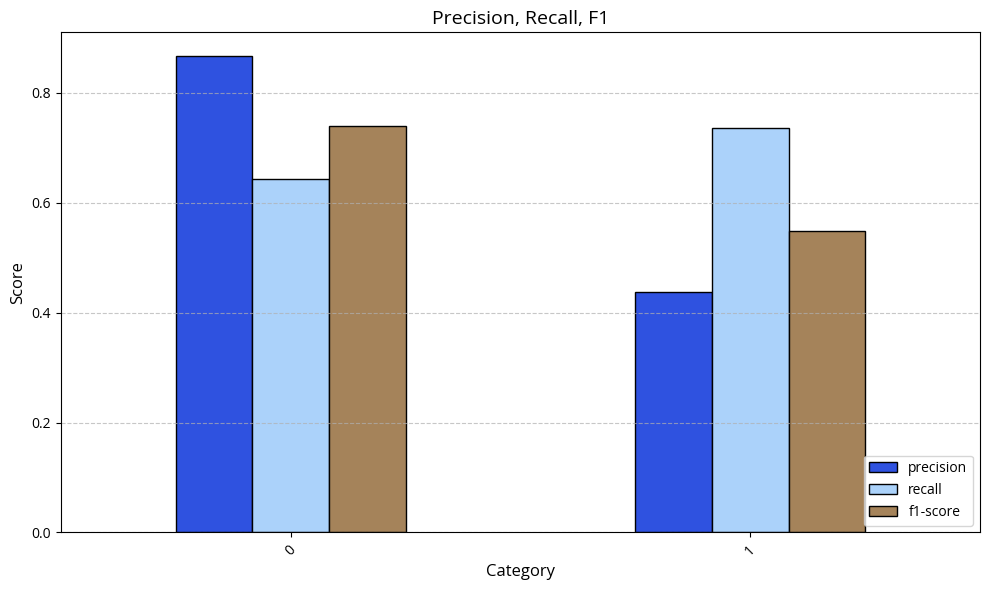

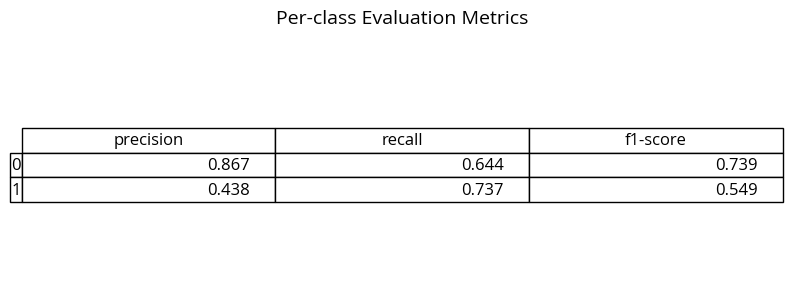

In [ ]:
#Deep Feed Forward NN — Word2Vec + Weighted sampler
import torch
from src.ML.train_NN_improved import FocalLoss
#X_train, X_test, y_train, y_test, w2vmodel = prepare_data_word2vec(df)

print('Deep Feed Forward NN — Weighted sampler')

model, class_to_idx, preds, labels, train_losses, test_accs = train_model(
    X_train, y_train, X_test, y_test,
    model_class=DeepTextClassifier,
    model_params={'hidden_dims': [256, 128, 64, 32]},
    epochs=150,
    lr=5e-4,
    sampler='weighted',
    use_scheduler=True
)
print("Input dimension for NN:", X_train.shape[1])

plot_results(class_to_idx, preds, labels, train_losses, test_accs)